# Notebook 1: Tu primer grafo con LangGraph

## ¿De qué trata este notebook?

Este es el punto de partida de una serie de 4 notebooks sobre **LangGraph**. Aquí aprenderás los bloques básicos con los que se construyen todos los sistemas de IA más avanzados.

### ¿Qué es LangGraph y por qué existe?

Una llamada simple a un modelo de IA (como Gemini) funciona así:
```
Tú escribes algo → el modelo responde → fin
```

Pero en un sistema real necesitas hacer varias cosas en orden:
```
Limpiar el texto → enviarlo al modelo → procesar la respuesta → guardar el resultado
```

LangGraph te permite definir ese flujo como un **grafo**: un diagrama de cajas conectadas con flechas.

### La analogía de la cadena de montaje

Piensa en una fábrica. Hay estaciones de trabajo (nodos) y una ficha viajera (el estado) que pasa de estación en estación. Cada estación lee la ficha, hace algo, escribe en ella, y la pasa a la siguiente.

### Qué aprenderás aquí

| Concepto | ¿Qué es? |
|----------|---------|
| **Estado** | La ficha viajera. Diccionario que acumula información entre nodos |
| **Nodo** | Una estación de trabajo. Función que recibe el estado y devuelve cambios |
| **Edge (arista)** | La flecha que conecta una estación con la siguiente |
| **Grafo** | El conjunto completo: todas las estaciones y flechas |
| **Compilar** | Convertir el diseño del grafo en algo ejecutable |
| **invoke / stream** |  Las formas de ejecutar el grafo |

**Proyecto:** mini-agente que recibe una pregunta → la limpia → la envía a Gemini → devuelve la respuesta.

---
## 1. Instalación de dependencias

Necesitamos dos librerías:
- `langgraph`: gestiona el grafo y el flujo de ejecución
- `langchain-google-genai`: conector para usar Gemini de Google

La línea está comentada (con `#`). Quita el `#` si necesitas instalarlas.

In [1]:
# %pip install -qU langgraph langchain-google-genai

---
## 2. Configuración de la API Key

Para hablar con Gemini, el código necesita una contraseña (API Key). La guardamos en un archivo `.env` para no escribirla en el código.

- `load_dotenv()` lee el archivo `.env` y carga sus variables
- `os.getenv("GEMINI_API_KEY")` recupera el valor guardado

Si estás en Google Colab, descomenta la segunda opción (`userdata.get`).

In [2]:
from dotenv import load_dotenv
import os

load_dotenv(dotenv_path="C:/Users/Oscar/OneDrive - FM4/Escritorio/EVOLVE/Data Science/EVOLVE/Victor_Prior_IA_Generativa/Proyecto_Modulo_IAGen/.env")
API_KEY = os.getenv("GEMINI_API_KEY_001")

# API key de Gemini
# API_KEY = userdata.get('GEMINI_API_KEY')

In [3]:
import google.generativeai as genai
import os

# 1. Configuración de la API Key
# Asegúrate de que la variable de entorno esté cargada o pásala directamente
genai.configure(api_key=os.getenv("GEMINI_API_KEY_001"))

# 2. Extracción filtrada
modelos_gemini = [
    m.name.split("/")[-1] 
    for m in genai.list_models() 
    if "generateContent" in m.supported_generation_methods 
    and "gemini" in m.name
]

# 3. Visualización directa
print(f"Modelos detectados: {len(modelos_gemini)}")
for modelo in modelos_gemini:
    print(f" - {modelo}")

c:\Users\Oscar\OneDrive - FM4\Escritorio\EVOLVE\Data Science\EVOLVE\Victor_Prior_IA_Generativa\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Oscar\AppData\Local\Temp\ipykernel_25192\522049115.py:1: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


Modelos detectados: 24
 - gemini-2.5-flash
 - gemini-2.5-pro
 - gemini-2.0-flash
 - gemini-2.0-flash-001
 - gemini-2.0-flash-lite-001
 - gemini-2.0-flash-lite
 - gemini-2.5-flash-preview-tts
 - gemini-2.5-pro-preview-tts
 - gemini-flash-latest
 - gemini-flash-lite-latest
 - gemini-pro-latest
 - gemini-2.5-flash-lite
 - gemini-2.5-flash-image
 - gemini-3-pro-preview
 - gemini-3-flash-preview
 - gemini-3.1-pro-preview
 - gemini-3.1-pro-preview-customtools
 - gemini-3.1-flash-lite-preview
 - gemini-3-pro-image-preview
 - gemini-3.1-flash-image-preview
 - gemini-3.1-flash-tts-preview
 - gemini-robotics-er-1.5-preview
 - gemini-robotics-er-1.6-preview
 - gemini-2.5-computer-use-preview-10-2025


---
## 3. Conceptos clave antes de empezar

### ¿Qué es un grafo en LangGraph?

LangGraph modela flujos de trabajo como **grafos dirigidos**:

```
[START] → [nodo_1] → [nodo_2] → [END]
```

- **Nodos**: funciones Python que reciben el estado actual y retornan una actualización del estado.
- **Edges**: conexiones entre nodos que determinan el flujo de ejecución.
- **Estado**: un diccionario (o clase TypedDict) que se pasa entre nodos y acumula la información.

### El estado es la clave

El estado es el "hilo conductor" del grafo. Cada nodo lo lee y lo modifica. Necesitamos definirlo con `TypedDict`.

---
## 4. Definir el Estado

### ¿Qué es el estado y por qué necesita una estructura?

El estado es la ficha viajera de la cadena de montaje. `TypedDict` define qué campos tiene esa ficha y de qué tipo son.

**Campos del estado:**
- `pregunta`: lo que pregunta el usuario (texto, llega desde fuera)
- `respuesta`: lo que genera el modelo (empieza vacío, lo rellena el nodo 2)
- `procesado`: si el modelo ya respondió (empieza en False, se pone en True al final)

**Lo que entra:** nada (es solo una definición de estructura)
**Lo que sale:** la plantilla que usarán todos los nodos del grafo

In [4]:
from typing import TypedDict

# El estado define qué información viaja a través del grafo.
# Cada campo puede ser leído y escrito por los nodos.
class EstadoAgente(TypedDict):
    pregunta: str       # La pregunta del usuario
    respuesta: str      # La respuesta generada por el modelo
    procesado: bool     # Si la pregunta ya fue procesada

print("Estado definido correctamente:", EstadoAgente.__annotations__)

Estado definido correctamente: {'pregunta': <class 'str'>, 'respuesta': <class 'str'>, 'procesado': <class 'bool'>}


---
## 5. Inicializar el modelo LLM

Creamos la conexión con Gemini. Parámetros importantes:
- `model`: versión de Gemini. `gemini-2.5-flash-lite` es la más rápida y económica
- `temperature=0.7`: creatividad de las respuestas. 0 = muy predecible, 1 = muy creativo

El resultado (`llm`) es el objeto que usaremos dentro de los nodos para llamar al modelo.

In [11]:
from langchain_google_genai import ChatGoogleGenerativeAI

# Inicializamos Gemini 2.5 Flash-Lite
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.7,
    api_key = API_KEY
)

print("Modelo inicializado:", llm.model)

Modelo inicializado: gemini-2.5-flash


---
## 6. Definir los Nodos

### ¿Qué es un nodo?

Un nodo es una función Python que sigue siempre la misma regla:
1. Recibe el estado completo como argumento
2. Hace algo con él
3. Devuelve **solo los campos que modificó** (no el estado completo)

LangGraph fusiona automáticamente lo que devuelve el nodo con el estado existente.

### Nodo 1: preprocesar
- **Qué hace:** limpia la pregunta quitando espacios y puntuación, y añade `?` al final
- **Qué devuelve:** `pregunta` limpia + `procesado = False`

### Nodo 2: responder
- **Qué hace:** envía la pregunta limpia a Gemini y recibe la respuesta
- **Qué devuelve:** `respuesta` del modelo + `procesado = True`

In [6]:
# Nodo 1: Preprocesar la pregunta
def nodo_preprocesar(estado: EstadoAgente) -> dict:
    """
    Este nodo limpia y prepara la pregunta antes de enviarla al LLM.
    Retorna solo los campos que quiere modificar.
    """
    pregunta_limpia = estado["pregunta"].strip().rstrip("?!") + "?"
    print(f"[Nodo Preprocesar] Pregunta original: '{estado['pregunta']}'")
    print(f"[Nodo Preprocesar] Pregunta limpia:   '{pregunta_limpia}'")
    
    return {
        "pregunta": pregunta_limpia,
        "procesado": False  # Aún no hemos procesado con el LLM
    }


# Nodo 2: Llamar al LLM
def nodo_responder(estado: EstadoAgente) -> dict:
    """
    Este nodo envía la pregunta al LLM y guarda la respuesta en el estado.
    """
    print(f"[Nodo Responder] Enviando al LLM: '{estado['pregunta']}'")
    
    respuesta = llm.invoke(estado["pregunta"])
    
    print(f"[Nodo Responder] Respuesta recibida (primeros 80 chars): '{respuesta.content[:80]}...'")
    
    return {
        "respuesta": respuesta.content,
        "procesado": True
    }


print("Nodos definidos: nodo_preprocesar, nodo_responder")

Nodos definidos: nodo_preprocesar, nodo_responder


---
## 7. Construir el Grafo

### ¿Qué es construir el grafo?

Aquí ensamblamos las piezas definidas antes. El proceso tiene 4 pasos:
1. Crear el contenedor del grafo con `StateGraph(EstadoAgente)` — le decimos qué estructura tiene el estado
2. Añadir cada nodo con `add_node("nombre", funcion)`
3. Dibujar las flechas con `add_edge("origen", "destino")`
4. Compilar con `compile()` — convierte el diagrama en una máquina ejecutable

**`START` y `END`** son nodos especiales predefinidos: representan el inicio y el final del flujo.

Flujo construido: `START → preprocesar → responder → END`

In [7]:
from langgraph.graph import StateGraph, START, END

# 1. Crear el grafo con nuestro estado
grafo = StateGraph(EstadoAgente)

# 2. Agregar los nodos
grafo.add_node("preprocesar", nodo_preprocesar)
grafo.add_node("responder",   nodo_responder)

# 3. Definir las conexiones (edges)
#    START → preprocesar → responder → END
grafo.add_edge(START, "preprocesar")
grafo.add_edge("preprocesar", "responder")
grafo.add_edge("responder", END)

# 4. Compilar el grafo (lo convierte en un objeto ejecutable)
app = grafo.compile()

print("✅ Grafo compilado correctamente")

✅ Grafo compilado correctamente


---
## 8. Visualizar el grafo (opcional)

LangGraph puede dibujar el grafo para que veas cómo están conectados los nodos:
- `draw_ascii()`: texto plano, siempre funciona
- `draw_mermaid_png()`: imagen, requiere librerías extra

La visualización es solo informativa — no afecta al funcionamiento.

In [8]:
# Visualización en ASCII (siempre disponible)
print(app.get_graph().draw_ascii())

 +-----------+   
 | __start__ |   
 +-----------+   
        *        
        *        
        *        
+-------------+  
| preprocesar |  
+-------------+  
        *        
        *        
        *        
 +-----------+   
 | responder |   
 +-----------+   
        *        
        *        
        *        
  +---------+    
  | __end__ |    
  +---------+    


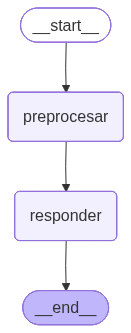

In [9]:
# Visualización con Mermaid (si estás en Jupyter/Colab)
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Visualización gráfica no disponible:", e)
    print("Usa draw_ascii() en su lugar")

---
## 9. Ejecutar el grafo

### ¿Cómo se ejecuta?

`app.invoke(estado_inicial)` es la forma estándar:
- Le pasas el **estado inicial** (la ficha con los valores de partida)
- El grafo ejecuta todos los nodos en orden
- Te devuelve el **estado final** (la ficha con todos los campos rellenos)

**Estado inicial:** debes dar un valor a todos los campos. Los que empiezan vacíos se llenarán a medida que el grafo avanza.

**Lo que sale:** `pregunta` limpia, `respuesta` del modelo, y `procesado = True`.

In [12]:
# Estado inicial: solo necesitamos la pregunta.
# Los demás campos se irán llenando a medida que el grafo avanza.
estado_inicial = {
    "pregunta": "¿Qué es la fotosíntesis",
    "respuesta": "",
    "procesado": False
}

print("=" * 60)
print("Ejecutando el grafo...")
print("=" * 60)

resultado = app.invoke(estado_inicial)

print("=" * 60)
print("Estado final del grafo:")
print("=" * 60)
print(f"Pregunta:  {resultado['pregunta']}")
print(f"Procesado: {resultado['procesado']}")
print(f"Respuesta:\n{resultado['respuesta']}")

Ejecutando el grafo...
[Nodo Preprocesar] Pregunta original: '¿Qué es la fotosíntesis'
[Nodo Preprocesar] Pregunta limpia:   '¿Qué es la fotosíntesis?'
[Nodo Responder] Enviando al LLM: '¿Qué es la fotosíntesis?'
[Nodo Responder] Respuesta recibida (primeros 80 chars): 'La **fotosíntesis** es un proceso vital que realizan las plantas, algas y alguna...'
Estado final del grafo:
Pregunta:  ¿Qué es la fotosíntesis?
Procesado: True
Respuesta:
La **fotosíntesis** es un proceso vital que realizan las plantas, algas y algunas bacterias para transformar la energía de la luz solar en energía química. Esencialmente, es la forma en que estos organismos "fabrican su propio alimento".

Aquí te lo explico en detalle:

### ¿Qué es la Fotosíntesis?

Es el proceso mediante el cual los organismos que contienen **clorofila** (un pigmento verde) utilizan la energía de la luz solar para convertir **dióxido de carbono (CO₂) y agua (H₂O)** en **glucosa (azúcar)**, que es su alimento, y **oxígeno (O₂)**, que 

---
## 10. Streaming: ver el estado nodo por nodo

### ¿Para qué sirve el streaming?

Con `invoke()` ejecutas todo y recibes el resultado final. Con `stream()` ves qué pasa **en cada paso**.

Es como ver la cadena de montaje en cámara lenta: ves exactamente qué escribió cada estación en la ficha.

**Lo que devuelve cada iteración:** `{nombre_del_nodo: cambios_que_hizo}`. Muy útil para depurar errores.

In [13]:
estado_inicial_2 = {
    "pregunta": "¿Cuántos planetas hay en el sistema solar?",
    "respuesta": "",
    "procesado": False
}

print("Ejecutando con streaming de estados...")
print("=" * 60)

for paso in app.stream(estado_inicial_2):
    # 'paso' es un diccionario: {nombre_nodo: estado_actualizado}
    for nombre_nodo, estado_actualizado in paso.items():
        print(f"\n📌 Nodo ejecutado: '{nombre_nodo}'")
        print(f"   Estado actualizado: {estado_actualizado}")

Ejecutando con streaming de estados...
[Nodo Preprocesar] Pregunta original: '¿Cuántos planetas hay en el sistema solar?'
[Nodo Preprocesar] Pregunta limpia:   '¿Cuántos planetas hay en el sistema solar?'

📌 Nodo ejecutado: 'preprocesar'
   Estado actualizado: {'pregunta': '¿Cuántos planetas hay en el sistema solar?', 'procesado': False}
[Nodo Responder] Enviando al LLM: '¿Cuántos planetas hay en el sistema solar?'
[Nodo Responder] Respuesta recibida (primeros 80 chars): 'Actualmente, hay **8 planetas** en nuestro sistema solar.

Son, en orden de cerc...'

📌 Nodo ejecutado: 'responder'
   Estado actualizado: {'respuesta': 'Actualmente, hay **8 planetas** en nuestro sistema solar.\n\nSon, en orden de cercanía al Sol:\n\n1.  **Mercurio**\n2.  **Venus**\n3.  **Tierra**\n4.  **Marte**\n5.  **Júpiter**\n6.  **Saturno**\n7.  **Urano**\n8.  **Neptuno**\n\nEs importante recordar que antes se consideraba que había 9 planetas, pero en 2006, Plutón fue reclasificado como un **planeta enano** por 

---
## 11. Ejercicios propuestos

1. **Agrega un tercer nodo** llamado `nodo_formatear` que tome la respuesta del LLM y la ponga en mayúsculas. Conéctalo entre `responder` y `END`.

2. **Añade un campo `idioma`** al estado. En `nodo_preprocesar`, agrega al prompt la instrucción "Responde en [idioma]".

3. **Mide el tiempo**: añade un campo `tiempo_ms` al estado y en `nodo_responder` calcula cuánto tardó la llamada al LLM.

## Resumen

| Concepto | Descripción |
|---|---|
| `TypedDict` | Define la estructura del estado compartido |
| `StateGraph` | El contenedor del grafo |
| `add_node` | Registra una función como nodo |
| `add_edge` | Conecta dos nodos en secuencia |
| `compile()` | Convierte el grafo en un ejecutable |
| `invoke()` | Ejecuta el grafo con un estado inicial |
| `stream()` | Ejecuta el grafo paso a paso, retornando cada estado intermedio |